In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

%matplotlib inline 


In [2]:
def accuracy(logits, y):
    preds = (torch.sigmoid(logits) > 0.5).float()
    return (preds == y).float().mean().item()

In [3]:
path = Path('nn/src/dataset')
train_dataset = pd.read_csv(path/'train.csv')
test_dataset = pd.read_csv(path/'test.csv')

### Data cleanup

In [4]:
train_df= train_dataset
test_df= test_dataset

cols_to_drop = ['PassengerId', 'Ticket', 'Cabin', 'Name']  

dep_var = 'Survived'

train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

age_median = train_df['Age'].median()
train_df['Age'] = train_df['Age'].fillna(age_median)
test_df['Age'] = test_df['Age'].fillna(age_median)

fare_median = train_df['Fare'].median()
test_df['Fare'] = test_df['Fare'].fillna(fare_median)

# drop na for embarked, just to try something new you know...
train_df = train_df.dropna(subset=['Embarked'])
test_df['Embarked'] = test_df['Embarked'].fillna('S')

embarked_map = {'S': 0, 'C': 1, 'Q': 2}
train_df['Embarked'] = train_df['Embarked'].map(embarked_map)
test_df['Embarked'] = test_df['Embarked'].map(embarked_map)

train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

In [5]:
cat_cols = ['Pclass', 'SibSp', 'Parch', 'Embarked', 'Sex']
cont_cols = ['Age', 'Fare']

### One-hot encoding

In [6]:
train_df = pd.get_dummies(train_df, columns=cat_cols)
test_df = pd.get_dummies(test_df, columns=cat_cols)
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)
test_df = test_df.drop(columns=[dep_var], errors='ignore')


### Normalize age and fare

In [7]:
for df in [train_df, test_df]:
    for col in cont_cols:
        m, s = train_df[col].mean(), train_df[col].std()
        df[col] = (df[col] - m) / s

### Prepare dataset

In [8]:
X = train_df.drop(columns=[dep_var]).astype('float32')
y = train_df[dep_var].astype('float32')

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_valid_t = torch.tensor(X_valid.values, dtype=torch.float32)
y_valid_t = torch.tensor(y_valid.values, dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
valid_ds = TensorDataset(X_valid_t, y_valid_t)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_dl = DataLoader(valid_ds, batch_size=64)

### Hyperparms

In [9]:
EPOCHS = 100
LEARNING_RATE = 1e-4

### Model

In [10]:
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 32),
    nn.LeakyReLU(),
    nn.Linear(32, 16),
    nn.LeakyReLU(),
    nn.Linear(16, 1)
)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.BCEWithLogitsLoss()

### Learn and visualize 

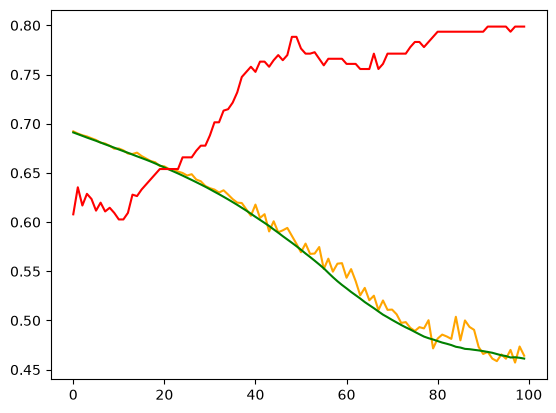

In [11]:
losses = []
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    valid_loss, valid_acc = 0, 0
    with torch.no_grad():
        for xb, yb in valid_dl:
            preds = model(xb)
            valid_loss += loss_fn(preds, yb).item()
            valid_acc += accuracy(preds, yb)

    losses.append((train_loss/len(train_dl), valid_loss/len(valid_dl), valid_acc/len(valid_dl)))

plt.plot([l[0] for l in losses], label="train", color="orange")
plt.plot([l[1] for l in losses], label="valid", color="green")
plt.plot([l[2] for l in losses], label="acc", color="red")
plt.show()

### Kaggle

In [12]:
X_test = test_df[X_train.columns].astype('float32')
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)

model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    preds = (torch.sigmoid(logits) > 0.5).int().squeeze()

submission = pd.DataFrame({
    'PassengerId': test_dataset['PassengerId'],
    'Survived': preds.numpy()
})

submission.to_csv(path/'submission.csv', index=False)
submission.head()

,PassengerId,Survived
0,892,1
1,893,1
2,894,1
3,895,1
4,896,1


In [13]:
len(submission)

418